**Connect Google Drive**


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


**Set Project Path**

In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/Crop_Disease_Project"

**Import Libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

**Load Saved Dataset**

In [ ]:
#Load compressed dataset
data = np.load(
    f"{PROJECT_PATH}/processed_data/dataset.npz"
)

images = data["images"]   #Extract images

labels = data["labels"]   #Extract labels

#Print dataset shapes
print(images.shape)
print(labels.shape)

(20637, 224, 224, 3)
(20637,)


**Check Total Classes**

In [ ]:
#Get unique class names
unique_classes = np.unique(labels)

print("Total Classes:", len(unique_classes))   #Print total classes

print(unique_classes)   #Print class names

Total Classes: 15
['Pepper__bell___Bacterial_spot' 'Pepper__bell___healthy'
 'Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy'
 'Tomato_Bacterial_spot' 'Tomato_Early_blight' 'Tomato_Late_blight'
 'Tomato_Leaf_Mold' 'Tomato_Septoria_leaf_spot'
 'Tomato_Spider_mites_Two_spotted_spider_mite' 'Tomato__Target_Spot'
 'Tomato__Tomato_YellowLeaf__Curl_Virus' 'Tomato__Tomato_mosaic_virus'
 'Tomato_healthy']


In this it identifies all unique disease categories present in the dataset.

**Show Sample Images**

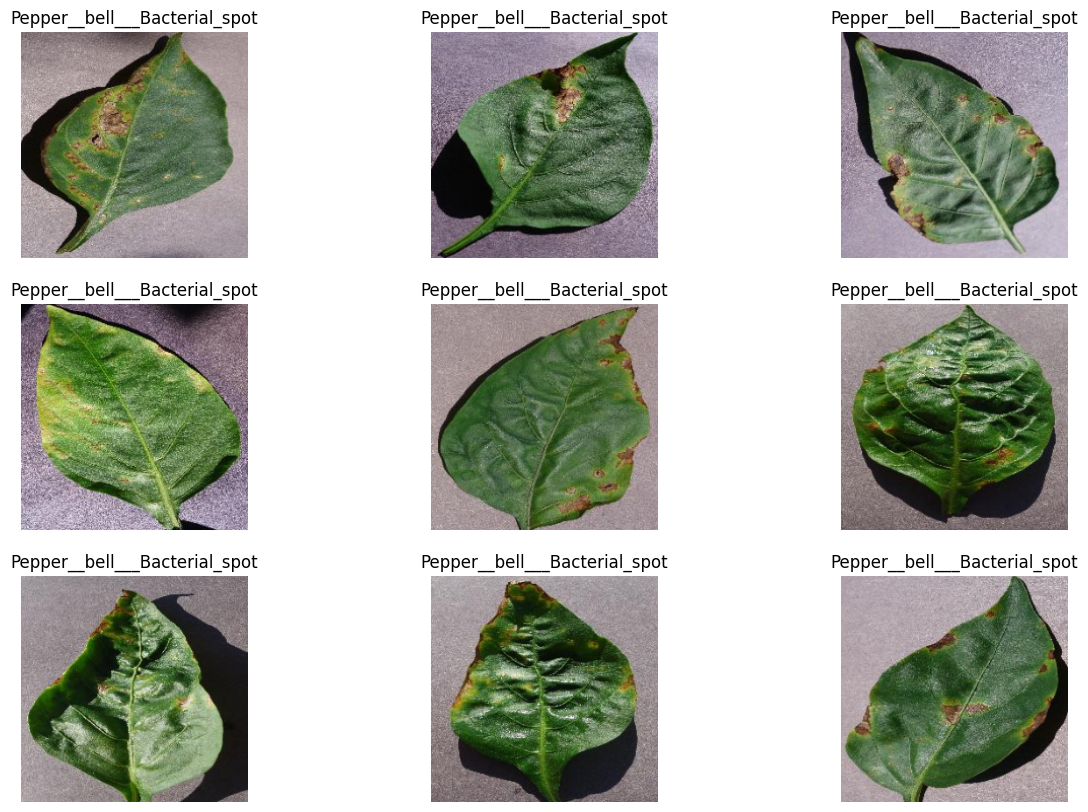

In [ ]:
#Create figure window
plt.figure(figsize=(15,10))

#Show first 9 images
for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(labels[i])

    plt.axis("off")

plt.show()

Displays sample plant leaf images along with their labels. It helps visually inspect image quality, disease patterns, dataset correctness

**Class Distribution**

In [ ]:
#Count images in every class
class_counts = Counter(labels)

#Store class names
class_names = list(class_counts.keys())

#Store image counts
counts = list(class_counts.values())

print(class_counts)   #Print class distribution

Counter({np.str_('Tomato__Tomato_YellowLeaf__Curl_Virus'): 3208, np.str_('Tomato_Bacterial_spot'): 2127, np.str_('Tomato_Late_blight'): 1909, np.str_('Tomato_Septoria_leaf_spot'): 1771, np.str_('Tomato_Spider_mites_Two_spotted_spider_mite'): 1676, np.str_('Tomato_healthy'): 1591, np.str_('Pepper__bell___healthy'): 1478, np.str_('Tomato__Target_Spot'): 1404, np.str_('Potato___Early_blight'): 1000, np.str_('Potato___Late_blight'): 1000, np.str_('Tomato_Early_blight'): 1000, np.str_('Pepper__bell___Bacterial_spot'): 996, np.str_('Tomato_Leaf_Mold'): 952, np.str_('Tomato__Tomato_mosaic_virus'): 373, np.str_('Potato___healthy'): 152})


Counts how many images belong to each disease category. Which helps to detects class imbalance,
overrepresented classes,
underrepresented classes.

**Plot Class Distribution**

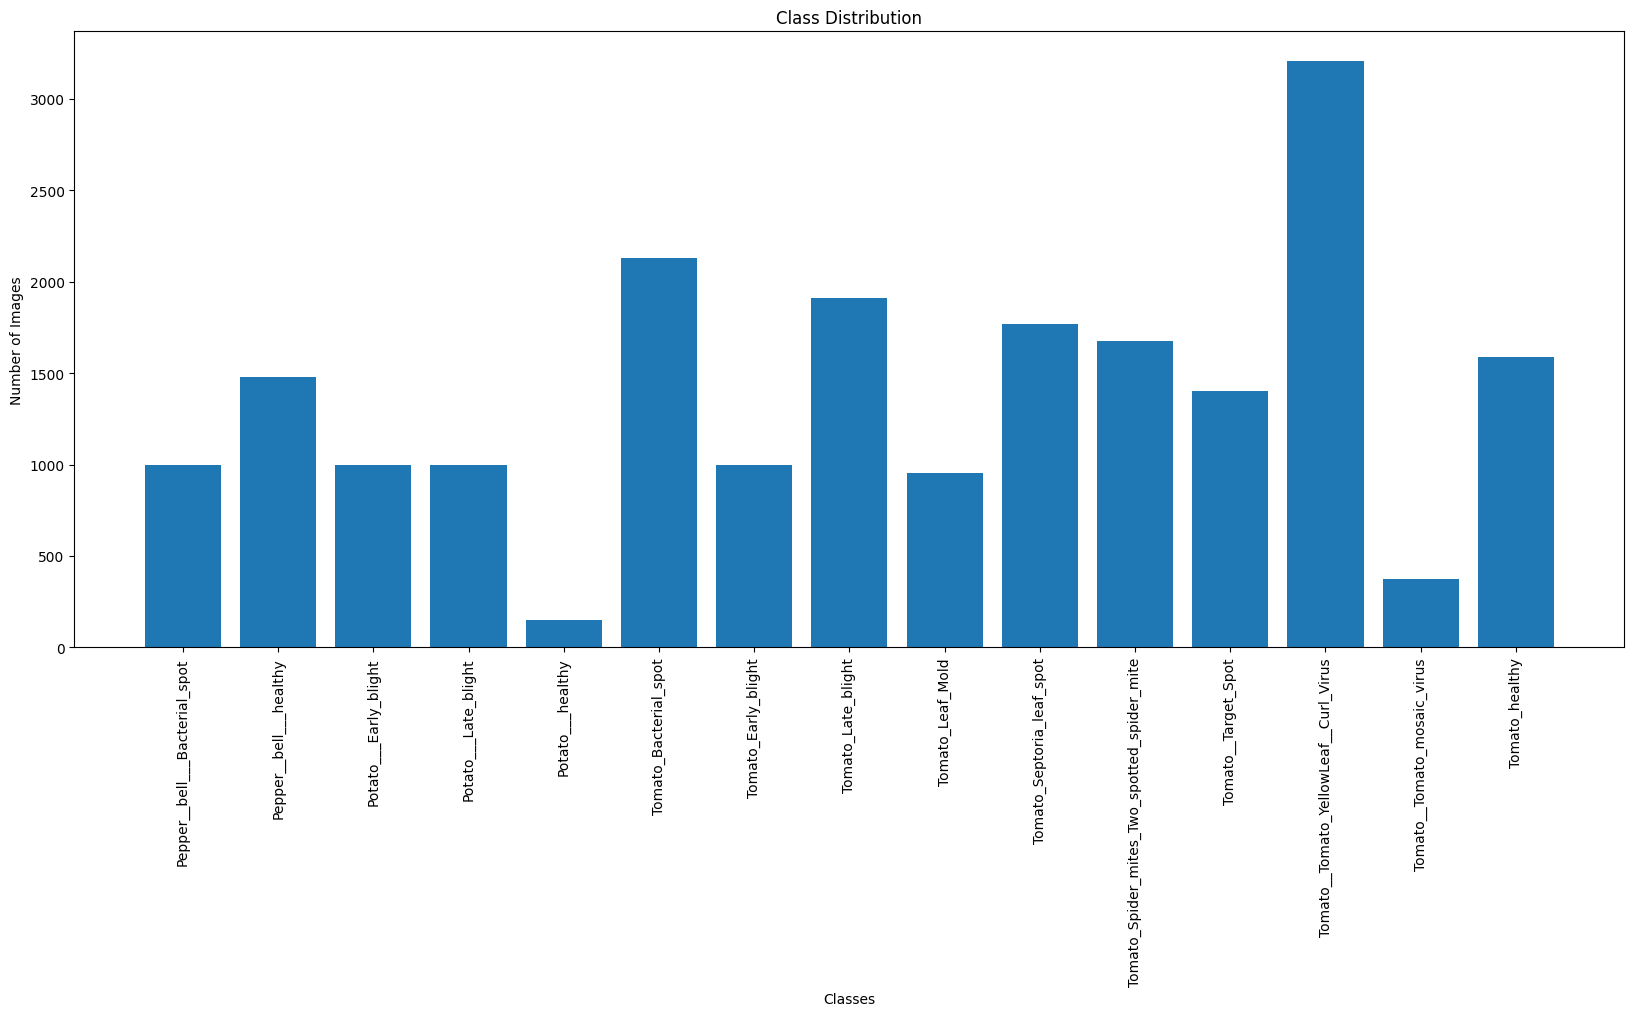

In [ ]:
plt.figure(figsize=(20,8))   #Create graph

plt.bar(class_names, counts)   #Create bar chart

plt.xticks(rotation=90)   #Rotate class (x-axis) labels

plt.title("Class Distribution")   #Graph title

plt.xlabel("Classes")   #X-axis label

plt.ylabel("Number of Images")   #Y-axis label

plt.show()

It Shows dataset distribution visually using a bar chart.

reference - https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html?utm_source=chatgpt.com

**Check Image Shape**

In [ ]:
#Print shape of first image
print("Image Shape:", images[0].shape)

Image Shape: (224, 224, 3)


Displays image dimensions.

**Check Image Data Type**

In [ ]:
#Print image datatype
print(images.dtype)

uint8


It Shows how image pixels are stored. It is useful before normalization and model training.

**Comapre Healthy and Diseased Leaves**

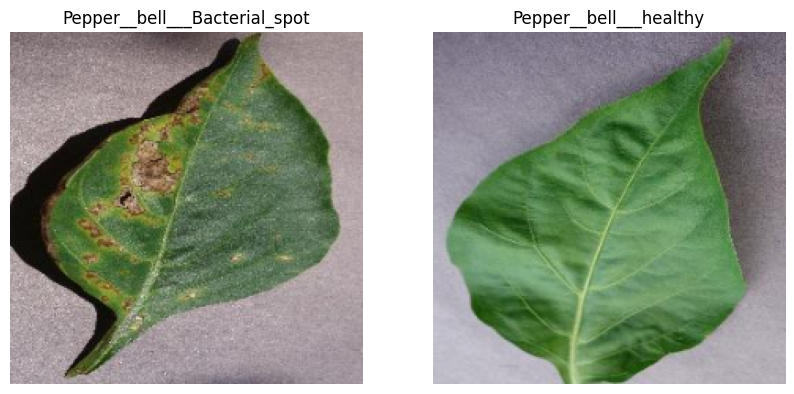

In [ ]:
#Select sample image indexes
healthy_index = 0
disease_index = 1000

plt.figure(figsize=(10,5))   #Create figure

#Healthy leaf image
plt.subplot(1,2,1)
plt.imshow(images[healthy_index])
plt.title(labels[healthy_index])
plt.axis("off")

#Diseased leaf image
plt.subplot(1,2,2)
plt.imshow(images[disease_index])
plt.title(labels[disease_index])
plt.axis("off")

plt.show()

Displays comparison between healthy and diseased leaf samples. It helps to understand visible disease symptoms before augmentation and model training.

**Optional - Create Folder for Graphs**

In [ ]:
import os

#Create graphs folder
os.makedirs(
    f"{PROJECT_PATH}/graphs",
    exist_ok=True
)

print("graphs folder created!")

graphs folder created!


Creates a separate folder to save generated graphs.

**Save Class Distribution Graph**

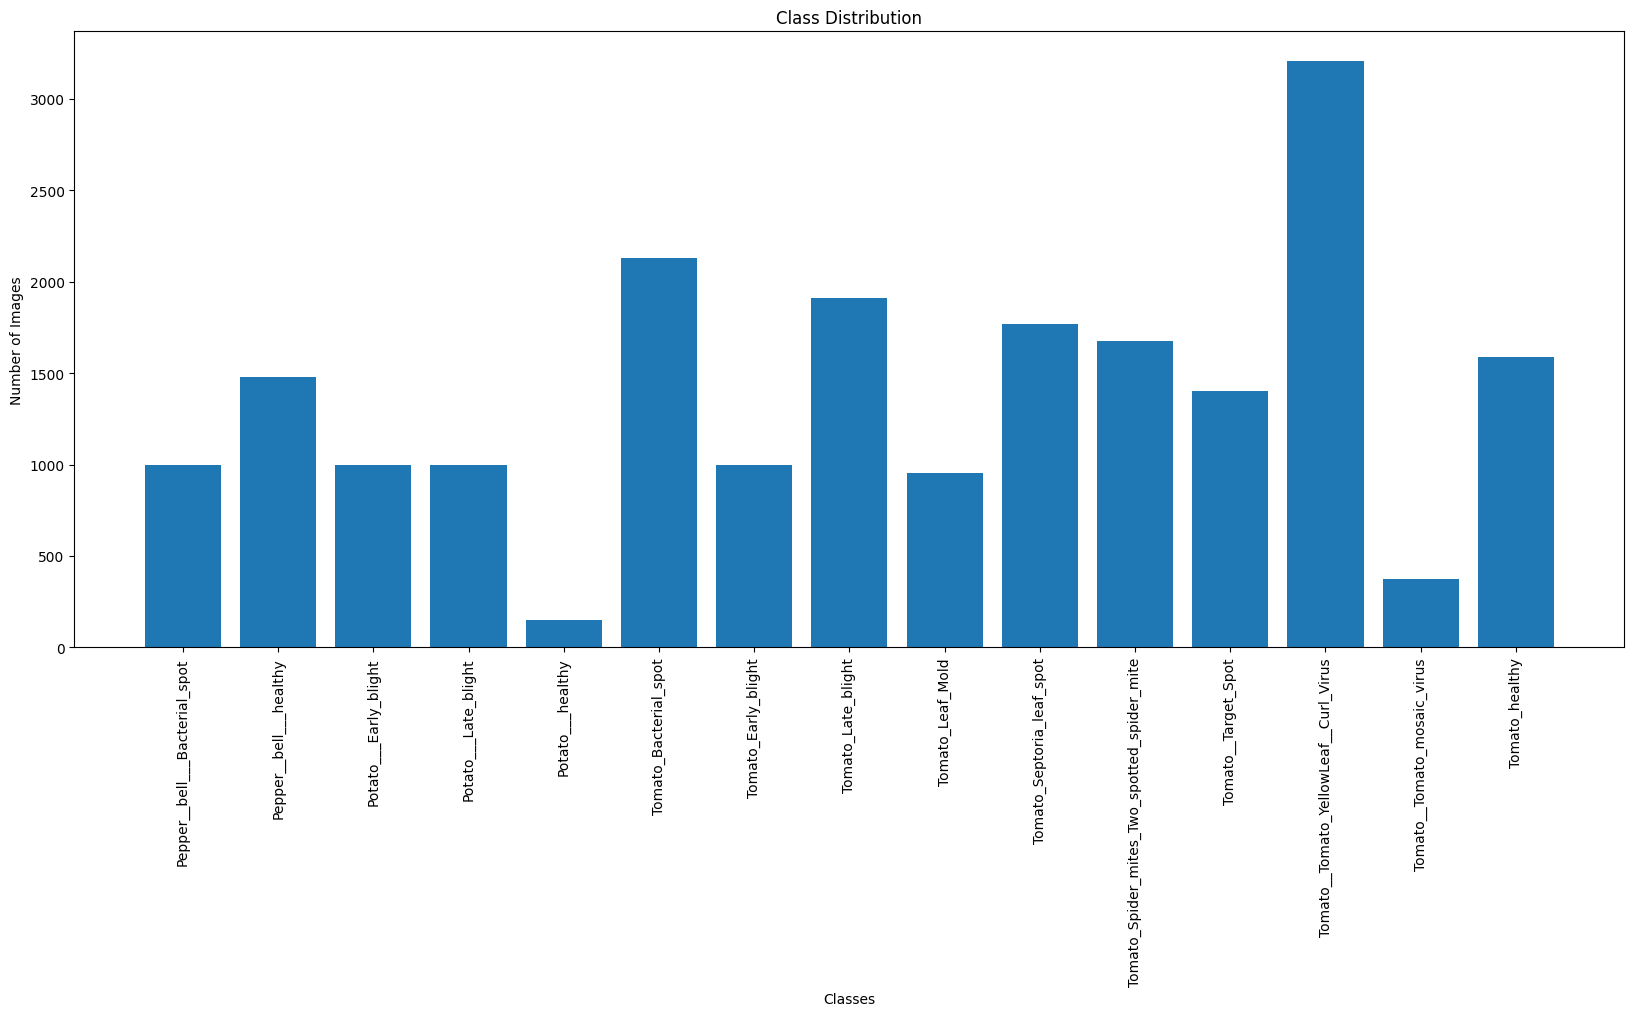

In [ ]:
plt.figure(figsize=(20,8))   #Create graph

plt.bar(class_names, counts)   #Plot bar chart

plt.xticks(rotation=90)   #Rotate class names

plt.title("Class Distribution")   #Add graph title

#Axis labels
plt.xlabel("Classes")
plt.ylabel("Number of Images")

#Save graph
plt.savefig(
    f"{PROJECT_PATH}/graphs/class_distribution.png"
)

plt.show()

Saves the class distribution graph as an image file. Which is useful for thesis documentation, reports, presentations, result analysis.

reference -
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html?utm_source=chatgpt.com